In [1]:
import cv2
import matplotlib.pyplot as plt

In [2]:
config_file = 'ssd_mobilenet_v3_large_coco_2020_01_14.pbtxt'
frozen_model = 'frozen_inference_graph.pb'

In [3]:
model = cv2.dnn_DetectionModel(frozen_model, config_file)

In [4]:
classLabels = []
file_name = 'Labels.txt'
with open(file_name, 'rt') as fpt:
    classLabels = fpt.read().rstrip('\n').split('\n')

print(classLabels)

['person', 'bicycle', 'car', 'motorbike', 'aeroplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'sofa', 'pottedplant', 'bed', 'diningtable', 'toilet', 'tvmonitor', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']


In [5]:
print(len(classLabels))

80


In [6]:
model.setInputSize(320, 320)
model.setInputScale(1.0 / 127.5)
model.setInputMean((127.5, 127.5, 127.5))
model.setInputSwapRB(True)

< cv2.dnn.Model 000002A349126430>

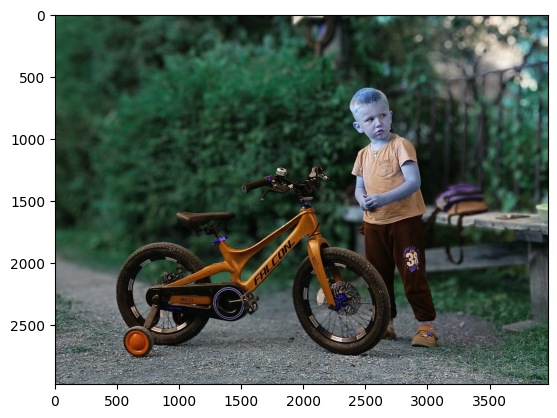

In [50]:
img = cv2.imread('boy.jpg')
plt.imshow(img)

In [85]:
img = cv2.imread('boy.jpg')
ClassIndex, confidence, bbox = model.detect(img, confThreshold=0.5)

In [77]:
print(ClassIndex)

[1 2 4]


In [86]:
font_scale = 5
font = cv2.FONT_HERSHEY_PLAIN
thickness = 3

offset = 0

for ClassInd, conf, box in zip(ClassIndex.flatten(), confidence.flatten(), bbox):
    x, y, w, h = box
    cv2.rectangle(img, box, (255, 0, 0), 2)
    label = f"{classLabels[ClassInd - 1]}: {conf*100:.1f}%"
    text_y = max(y - 10 - offset, 30)
    cv2.rectangle(img, (x, text_y - 25), (x + 300, text_y), (255, 0, 0), -1)
    cv2.putText(img, label, (x + 5, text_y - 5), font, fontScale=font_scale,
                color=(0, 255, 0), thickness=thickness)
    offset += 70

In [79]:
print("Classes:", ClassIndex)
print("Confidences:", confidence)
print("Boxes:", bbox)

Classes: [1 2 4]
Confidences: [0.7629901 0.6914403 0.6244244]
Boxes: [[2370  618  725 2067]
 [ 490 1189 2191 1561]
 [ 490 1189 2191 1561]]


In [ ]:
scale_percent = 25
width = int(img.shape[1] * scale_percent / 100)
height = int(img.shape[0] * scale_percent / 100)
resized = cv2.resize(img, (width, height), interpolation=cv2.INTER_AREA)

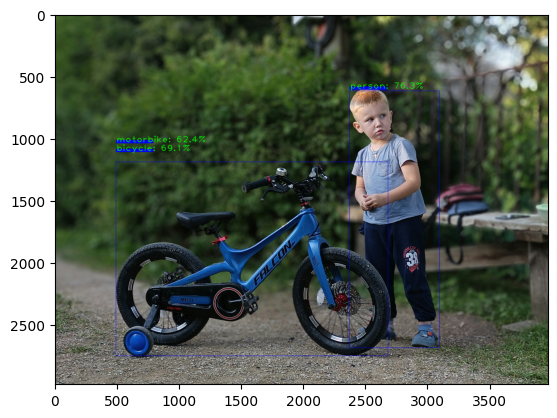

In [87]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

In [92]:
cap = cv2.VideoCapture('video.mp4')
if not cap.isOpened():
    cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise IOError("Cannot open video")

font_scale = 3
font = cv2.FONT_HERSHEY_PLAIN
thickness = 3

while True:
    ret, frame = cap.read()
    if not ret:
        break

    ClassIndex, confidence, bbox = model.detect(frame, confThreshold=0.55)

    print(ClassIndex)

    if len(ClassIndex) != 0:
        for ClassInd, conf, box in zip(ClassIndex.flatten(), confidence.flatten(), bbox):
            if ClassInd <= 80:
                x, y, w, h = box
                cv2.rectangle(frame, box, (255, 0, 0), 2)
                label = f"{classLabels[ClassInd - 1]}: {conf*100:.1f}%"
                text_y = max(y - 20, 30)
                text_height = int(30 * font_scale / 3)
                cv2.rectangle(frame, (x, text_y - text_height), (x + 300, text_y), (255, 0, 0), -1)
                cv2.putText(frame, label, (x + 5, text_y - 5), font, fontScale=font_scale,
                            color=(0, 255, 0), thickness=thickness)

    cv2.imshow('Object Detection', frame)
    if cv2.waitKey(2) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


[4 4 1 4 3 1 4 4 1 4 4 4 4]
[4 1 3 4 4 4 4 1 4 1 1 4 1 3 4]
[4 4 3 1 4 1 4 1 4 1 1 3 4 3 1 3 3]
[4 3 4 3 1 1 4 4 3 3 4 1 4 1 1 3 4]
[4 4 3 3 1 1 4 4 4 3 4 1 1 1 3 3 1]
[4 3 4 4 4 1 3 1 3 4 4 1 1 1 1 3 3]
[4 4 3 4 4 4 1 1 4 4 1 3 1 3 1 1 1]
[4 4 3 4 4 1 1 3 4 3 1 4 3 1 1 4]
[4 4 3 1 4 4 1 3 3 4 3 1 4]
[4 4 3 1 4 1 3 4 3 1 4]
[4 4 3 4 1 1 4 3 1 1 1 4 3 4 1 4]
[4 4 3 4 1 4 4 3 1 1 1 3 1 4 1 4 1]
[4 4 3 4 1 4 1 4 1 4 3 4 1 3 1 1 1 1 3 1]
[4 3 4 1 4 4 4 4 1 1 1 1 3 4 1 4 1 1 3]
[4 3 4 4 1 4 1 4 1 3 4 1 1 1 3 1 1]
[4 4 3 4 1 1 1 4 3 4 1 3 1 1 3]
[4 4 3 4 1 4 3 4 1 1 1 3 1 1 4 1]
[4 4 4 3 3 1 1 4 1 3 1 4 4 1]
[4 4 3 4 3 1 4 1 1 1 3]
[4 4 4 3 1 1 3 4 1 3 1 1]
[4 4 3 4 1 1 3 4 1 4 1 3 4 4 4]
[4 4 3 4 3 4 1 1 1 4 1 4 3 1 4 4]
[4 4 4 3 3 1 1 4 1 1 4 4 3 4 1 1]
[4 4 4 3 1 4 1 1 3 4 1 1 3 4 4]
[4 4 4 3 1 1 1 3 4 1 1 4 3]
[4 4 3 1 1 4 3 1 1 4 4 1 3]
[4 4 3 1 3 4 1 4 1 1 3 4 1 3 1]
[4 4 3 1 4 1 4 3 1 1 1 4 1 1 4]
[4 4 3 1 4 1 4 1 1 1 1 1 4 4]
[4 4 4 3 1 1 4 4 4 1 1 4 1 1 1]
[4 4 4 3 1 1 4 4 4 1 4 1 4